<a href="https://colab.research.google.com/github/jaysplash208/Rainfall-prediction-project/blob/main/rainfall_prediction_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('weatherAUS.csv')

# 2. Immediate Drop: Date causes 3,000+ fake features.
# Evaporation, Sunshine, and Clouds have 40%+ missing data—they'll just confuse the model.
cols_to_drop = ['Date', 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
df.drop(columns=cols_to_drop, inplace=True)

# 3. Drop rows where we don't have the answer (RainTomorrow)
df.dropna(subset=['RainTomorrow'], inplace=True)

print("Stage 1 Complete: Data loaded and 'noise' removed.")
print(f"Current columns: {df.shape[1]}")

Stage 1 Complete: Data loaded and 'noise' removed.
Current columns: 18


In [12]:
 # 1. Fill missing numbers with the Median (middle value)
numerical = df.select_dtypes(include=[np.number]).columns
for col in numerical:
    df[col] = df[col].fillna(df[col].median())

# 2. Fill missing text with the Mode (most common value)
categorical = df.select_dtypes(include=['object']).columns
for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Map the Target: This is crucial so the name stays 'RainTomorrow'
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 4. One-Hot Encoding: Turn Cities/Wind into 0s and 1s
df_final = pd.get_dummies(df, drop_first=True)

print("Stage 2 Complete: Missing values filled and text converted to numbers.")
print(f"Final Feature Count: {df_final.shape[1] - 1}")

Stage 2 Complete: Missing values filled and text converted to numbers.
Final Feature Count: 83


In [13]:

X = df_final.drop('RainTomorrow', axis=1)
y = df_final['RainTomorrow']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Making sure all numbers are on the same 'scale')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Stage 3 Complete: Data is split and scaled.")
print(f"Final training features: {X_train_scaled.shape[1]}")

Stage 3 Complete: Data is split and scaled.
Final training features: 83


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it
rf_model.fit(X_train_scaled, y_train)

# Test it
predictions = rf_model.predict(X_test_scaled)

print(" RANDOM FOREST RESULTS ")
print(classification_report(y_test, predictions))

 RANDOM FOREST RESULTS 
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     11537
           1       0.77      0.43      0.55      3240

    accuracy                           0.85     14777
   macro avg       0.81      0.70      0.73     14777
weighted avg       0.84      0.85      0.83     14777



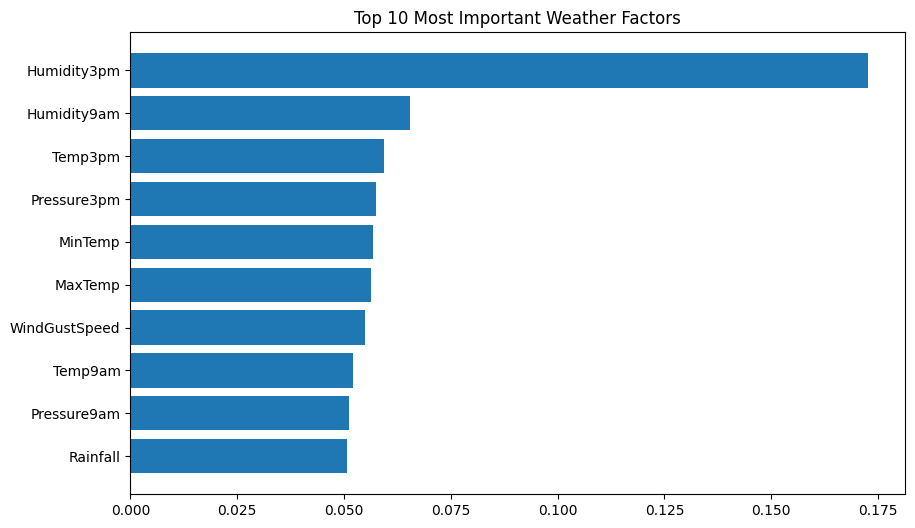

In [15]:
# See which of the 106 features are the most important
import matplotlib.pyplot as plt

# Get the importance levels
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the Top 10
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Most Important Weather Factors')
plt.show()

In [16]:
# 1. Train a new Random Forest with "Balanced" weights
# This tells the AI to treat Rain days as more important
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train_scaled, y_train)

# 2. Test it on the same unseen data
balanced_predictions = rf_balanced.predict(X_test_scaled)

print("BALANCED MODEL RESULTS ")
print(classification_report(y_test, balanced_predictions))

BALANCED MODEL RESULTS 
              precision    recall  f1-score   support

           0       0.85      0.96      0.91     11537
           1       0.76      0.42      0.54      3240

    accuracy                           0.84     14777
   macro avg       0.81      0.69      0.72     14777
weighted avg       0.83      0.84      0.83     14777



In [17]:
# 1. Get the probabilities instead of just 0 or 1
# This gives us the % chance the AI thinks it will rain
probabilities = rf_balanced.predict_proba(X_test_scaled)[:, 1]

# 2. Lower the "alarm" threshold to 30%
# If probability > 0.3, we predict Rain (1)
custom_predictions = (probabilities > 0.3).astype(int)

print(" THRESHOLD ADJUSTED RESULTS (30% Alarm) ")
print(classification_report(y_test, custom_predictions))

 THRESHOLD ADJUSTED RESULTS (30% Alarm) 
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     11537
           1       0.60      0.66      0.63      3240

    accuracy                           0.83     14777
   macro avg       0.75      0.77      0.76     14777
weighted avg       0.84      0.83      0.83     14777



In [18]:
import joblib

# 1. Save the model
joblib.dump(rf_balanced, 'weather_model.pkl')

# 2. Save the scaler (Crucial! You need this to process new data later)
joblib.dump(scaler, 'weather_scaler.pkl')

print("Success! Your model and scaler are saved as .pkl files.")
print("You can find them in the folder icon on the left of your Colab screen.")

Success! Your model and scaler are saved as .pkl files.
You can find them in the folder icon on the left of your Colab screen.


In [19]:
# Pick a random day from the test set
import random
i = random.randint(0, len(X_test))

# Make a prediction
sample_data = X_test_scaled[i].reshape(1, -1)
prediction = rf_balanced.predict(sample_data)[0]
actual = y_test.values[i]

print(f" REAL WORLD TEST ")
print(f"AI Prediction: {'RAIN' if prediction == 1 else 'NO RAIN'}")
print(f"Actual Weather: {'RAIN' if actual == 1 else 'NO RAIN'}")

if prediction == actual:
    print(" THE AI WAS RIGHT!")
else:
    print(" MISTAKES HAPPEN, BUT THAT'S SCIENCE!")

 REAL WORLD TEST 
AI Prediction: NO RAIN
Actual Weather: NO RAIN
 THE AI WAS RIGHT!


In [27]:
# 1. Let's grab one specific row to use as a template
sample_row = X_test.iloc[5].copy()

# 2. Let's make it a very DRY, SUNNY day manually
sample_row['Humidity3pm'] = 10.0  # Very dry
sample_row['Pressure3pm'] = 1025.0 # High pressure (usually clear skies)
sample_row['Rainfall'] = 0.0

# Scale it and predict
dry_day_scaled = scaler.transform([sample_row])
dry_prediction = rf_balanced.predict(dry_day_scaled)

# 3. Now let's take that SAME day and make it a STORM
sample_row['Humidity3pm'] = 91.0  # Super humid
sample_row['Pressure3pm'] = 910.0  # Very low pressure (stormy)
sample_row['Rainfall'] = 10.0

stormy_day_scaled = scaler.transform([sample_row])
stormy_prediction = rf_balanced.predict(stormy_day_scaled)

print(f"Scenario 1 (Dry/High Pressure): AI says {'RAIN' if dry_prediction[0] == 1 else 'NO RAIN'}")
print(f"Scenario 2 (Humid/Low Pressure): AI says {'RAIN' if stormy_prediction[0] == 1 else 'NO RAIN'}")

Scenario 1 (Dry/High Pressure): AI says NO RAIN
Scenario 2 (Humid/Low Pressure): AI says RAIN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
